In [1]:
import os
import nltk
import numpy as np

from typing import List, Optional, TypedDict

from dotenv import load_dotenv

from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.document_loaders import PyMuPDFLoader

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document

from rank_bm25 import BM25Okapi

from sentence_transformers import SentenceTransformer, CrossEncoder

from sklearn.metrics.pairwise import cosine_similarity

from langgraph.graph import StateGraph

from groq import Groq

In [2]:
nltk.download("punkt")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [3]:
load_dotenv()

GROQ_API_KEY = os.getenv("GROQ_API_KEY")

In [4]:
client = Groq(api_key=GROQ_API_KEY)

def llm(prompt):

    completion = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[{"role":"user","content":prompt}],
        temperature=0.2
    )

    return completion.choices[0].message.content

In [5]:
# Embedding + Reranker Models

embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-base-en-v1.5"
)

semantic_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

cross_encoder = CrossEncoder(
    "BAAI/bge-reranker-base"
)

C:\Users\user\AppData\Local\Temp\ipykernel_2916\3976762380.py:3: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(
c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when

In [6]:
def load_documents(path):

    loader = PyMuPDFLoader(path)

    docs = loader.load()

    return docs

In [7]:
def semantic_chunk(text, threshold=0.75):

    sentences = nltk.sent_tokenize(text)

    if len(sentences) <= 1:
        return sentences

    embeddings_sent = semantic_model.encode(sentences)

    chunks = []
    current = [sentences[0]]

    for i in range(1, len(sentences)):

        sim = np.dot(embeddings_sent[i], embeddings_sent[i-1]) / (
            np.linalg.norm(embeddings_sent[i]) *
            np.linalg.norm(embeddings_sent[i-1])
        )

        if sim < threshold:

            chunks.append(" ".join(current))
            current = []

        current.append(sentences[i])

    chunks.append(" ".join(current))

    return chunks

In [8]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=100
)

def adaptive_chunk(text):

    semantic_chunks = semantic_chunk(text)

    final_chunks = []

    for chunk in semantic_chunks:

        splits = splitter.split_text(chunk)

        final_chunks.extend(splits)

    return final_chunks

In [9]:
def hierarchical_split(docs):

    parent_docs = []
    child_docs = []

    for doc in docs:

        parents = semantic_chunk(doc.page_content)

        for parent in parents:

            parent_docs.append(Document(page_content=parent))

            children = adaptive_chunk(parent)

            for child in children:

                child_docs.append(
                    Document(
                        page_content=child,
                        metadata={"parent":parent}
                    )
                )

    return parent_docs, child_docs

In [10]:
document_vectorstore = None
document_bm25 = None
document_corpus = None

legal_vectorstore = None
legal_bm25 = None
legal_corpus = None

In [11]:
def build_document_retriever(child_docs):

    global document_vectorstore
    global document_bm25
    global document_corpus

    document_vectorstore = Chroma.from_documents(
        documents=child_docs,
        embedding=embeddings,
        persist_directory="./doc_chroma"
    )

    corpus = [doc.page_content for doc in child_docs]

    tokenized = [c.split() for c in corpus]

    document_corpus = corpus

    document_bm25 = BM25Okapi(tokenized)

In [12]:
# Load Existing Legal Vector DB

DB_PATH = r"C:\Users\user\Desktop\RAG Projects\Legal RAG 1\vector_database"

legal_vectorstore = Chroma(
    persist_directory=DB_PATH,
    embedding_function=embeddings,
    collection_name="legal_knowledge"
)

docs = legal_vectorstore.get()

legal_corpus = docs["documents"]

tokenized_corpus = [doc.split() for doc in legal_corpus]

legal_bm25 = BM25Okapi(tokenized_corpus)

C:\Users\user\AppData\Local\Temp\ipykernel_2916\889259884.py:5: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  legal_vectorstore = Chroma(


In [13]:
# Reciprocal Rank Fusion
def rrf_fusion(vector_docs, bm25_docs, k=60):

    scores = {}

    for rank, doc in enumerate(vector_docs):
        key = doc.page_content
        scores[key] = scores.get(key, 0) + 1/(k+rank)

    for rank, doc in enumerate(bm25_docs):
        key = doc.page_content
        scores[key] = scores.get(key, 0) + 1/(k+rank)

    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)

    return [Document(page_content=doc) for doc,_ in ranked]

In [14]:
def document_search(query, k=8):

    if document_vectorstore is None:
        return []

    vector_docs = document_vectorstore.similarity_search(query, k=k)

    scores = document_bm25.get_scores(query.split())

    idx = np.argsort(scores)[::-1][:k]

    bm25_docs = [Document(page_content=document_corpus[i]) for i in idx]

    return rrf_fusion(vector_docs, bm25_docs)

In [15]:
def legal_search(query, k=8):

    vector_docs = legal_vectorstore.similarity_search(query, k=k)

    scores = legal_bm25.get_scores(query.split())

    idx = np.argsort(scores)[::-1][:k]

    bm25_docs = [Document(page_content=legal_corpus[i]) for i in idx]

    return rrf_fusion(vector_docs, bm25_docs)

In [16]:
def rerank(query, docs, top_k=6):

    pairs = [(query, d.page_content) for d in docs]

    scores = cross_encoder.predict(pairs)

    ranked = sorted(
        zip(docs, scores),
        key=lambda x: x[1],
        reverse=True
    )

    return [doc for doc,_ in ranked[:top_k]]

In [17]:
def rewrite_query(query):

    prompt=f"""
Rewrite the legal query to improve retrieval.

Query:
{query}

Return only improved query.
"""

    return llm(prompt)

In [19]:
def strategist_decision(query):

    prompt=f"""
Decide which research agent should answer.

Options:
LEGAL
DOCUMENT
BOTH

Question:
{query}

Return only one word.
"""

    return llm(prompt).strip()

In [20]:
class LegalState(TypedDict):

    question: str
    rewritten_query: Optional[str]
    strategy: Optional[str]
    legal_docs: Optional[List]
    document_docs: Optional[List]
    final_docs: Optional[List]
    answer: Optional[str]
    critique: Optional[str]

In [21]:
def rewrite_agent(state):

    rq = rewrite_query(state["question"])

    return {"rewritten_query":rq}

In [59]:
import os
from typing import TypedDict, Optional

# 1. Resolve LLM dependencies
from langchain_groq import ChatGroq

# 2. Define the State
class AgentState(TypedDict):
    question: str
    uploaded_file: Optional[str]
    strategy: Optional[str]
    # Add any other keys your graph uses here (e.g., final_docs, answer)

# 3. Explicitly initialize the LLM
# FIX: Updated the model string to an active Groq Llama 3.1 endpoint
routing_llm = ChatGroq(
    model="llama-3.1-8b-instant", # Replaced the decommissioned 'llama3-8b-8192'
    temperature=0, 
    max_tokens=10
)

def strategist_agent(state: AgentState):
    print("---STRATEGIST AGENT---")
    question = state["question"]
    uploaded_file = state.get("uploaded_file")
    
    file_context = ""
    if uploaded_file:
        filename = os.path.basename(uploaded_file)
        clean_filename = filename.replace("_", " ").replace(".pdf", "").replace(".PDF", "")
        file_context = f"\nCRITICAL CONTEXT: An uploaded case document is available regarding '{clean_filename}'. If the user's question mentions this case, these parties, or asks for specifics not found in general law, you MUST route to DOCUMENT or BOTH."
    
    prompt = f"""You are an intelligent routing agent managing a legal RAG system.
    Analyze the following question and choose the appropriate retrieval strategy.
    
    Question: "{question}"
    {file_context}
    
    Options:
    - LEGAL: Use this ONLY for general Indian Law or Constitutional queries that do not relate to the uploaded document.
    - DOCUMENT: Use this if the query asks for specific details, plaintiffs, defendants, dates, or issues regarding the uploaded case document.
    - BOTH: Use this if the query requires combining general constitutional principles with the specific facts of the uploaded document.
    
    Return ONLY the exact word LEGAL, DOCUMENT, or BOTH. Do not include any other text, reasoning, or punctuation.
    """
    
    # 4. Use the correctly initialized LLM
    response = routing_llm.invoke(prompt)
    
    strategy = response.content.strip().upper()
    
    valid_strategies = ["LEGAL", "DOCUMENT", "BOTH"]
    if strategy not in valid_strategies:
        print(f"Warning: Unrecognized strategy '{strategy}'. Defaulting to safe route.")
        strategy = "BOTH" if uploaded_file else "LEGAL"
        
    print(f"Decision: Routed to {strategy}")
    return {"strategy": strategy}

In [23]:
def legal_agent(state):

    docs = legal_search(state["rewritten_query"])

    return {"legal_docs":docs}

In [24]:
def document_agent(state):

    docs = document_search(state["rewritten_query"])

    return {"document_docs":docs}

In [25]:
def fusion_agent(state):

    docs = []

    if state.get("legal_docs"):
        docs.extend(state["legal_docs"])

    if state.get("document_docs"):
        docs.extend(state["document_docs"])

    docs = rerank(state["rewritten_query"], docs)

    return {"final_docs":docs}

In [26]:
def answer_agent(state):

    context = "\n\n".join([d.page_content for d in state["final_docs"]])

    prompt=f"""
Answer the legal question using context.

Context:
{context}

Question:
{state['question']}
"""

    ans = llm(prompt)

    return {"answer":ans}

In [27]:
def critic_agent(state):

    prompt=f"""
Evaluate the answer.

Question:
{state['question']}

Answer:
{state['answer']}

Is the answer correct and grounded?
Explain briefly.
"""

    critique = llm(prompt)

    return {"critique":critique}

In [28]:
def router(state):
    if state["strategy"] == "LEGAL":
        return "legal"
    elif state["strategy"] == "DOCUMENT":
        return "document"
    else:
        # Return the list of nodes directly from the router to trigger parallel execution
        return ["legal", "document"]

In [60]:
workflow = StateGraph(LegalState)

workflow.add_node("rewrite", rewrite_agent)
workflow.add_node("strategist", strategist_agent)
workflow.add_node("legal", legal_agent)
workflow.add_node("document", document_agent)
workflow.add_node("fusion", fusion_agent)
workflow.add_node("answer", answer_agent)
workflow.add_node("critic", critic_agent)

workflow.set_entry_point("rewrite")

workflow.add_edge("rewrite","strategist")

workflow.add_conditional_edges(
    "strategist",
    router,
    # Map the single string outputs. The list output will be handled natively by LangGraph.
    ["legal", "document"] 
)

workflow.add_edge("legal","fusion")
workflow.add_edge("document","fusion")
workflow.add_edge("fusion","answer")
workflow.add_edge("answer","critic")

graph = workflow.compile()

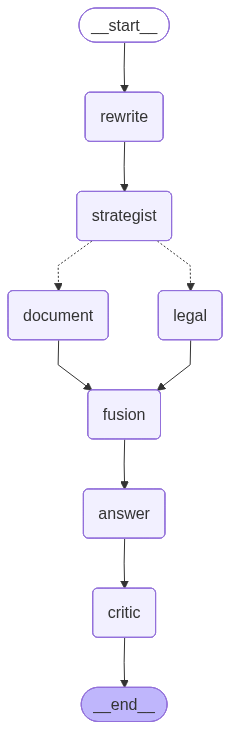

In [47]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [61]:
def legal_agentic_rag(question, uploaded_file=None):

    if uploaded_file:

        docs = load_documents(uploaded_file)

        parents, children = hierarchical_split(docs)

        build_document_retriever(children)

    state = {
        "question": question
    }

    result = graph.invoke(state)

    answer = result["answer"]

    context_docs = result.get("final_docs", [])

    return answer, context_docs

In [31]:
evaluation_dataset = [

    {
        "question": "If a state law conflicts with a central law in India, which prevails?",
        "ground_truth": "Central law prevails under Article 254 of the Indian Constitution."
    },

    {
        "question": "Which article guarantees equality before law?",
        "ground_truth": "Article 14 guarantees equality before law."
    },

    {
        "question": "Which article of the Constitution deals with freedom of speech?",
        "ground_truth": "Article 19 guarantees freedom of speech and expression."
    }

]

In [32]:
def answer_similarity(answer, ground_truth):

    answer_emb = embeddings.embed_query(answer)

    truth_emb = embeddings.embed_query(ground_truth)

    similarity = cosine_similarity(
        [answer_emb],
        [truth_emb]
    )[0][0]

    return float(similarity)

In [33]:
def hallucination_check(question, answer):

    prompt = f"""
You are a legal evaluation system.

Determine whether the answer contains hallucinated or fabricated legal information.

Question:
{question}

Answer:
{answer}

Respond ONLY with one word:

PASS
FAIL
"""

    result = llm(prompt).strip().upper()

    if "PASS" in result:
        return "PASS"
    else:
        return "FAIL"

In [36]:
def evaluate_rag_system(dataset):

    results = []

    for sample in dataset:
        question = sample["question"]
        ground_truth = sample["ground_truth"]
        
        # FIX: Unpack the tuple. We use '_' for docs if they aren't needed here.
        answer, _ = legal_agentic_rag(question) 
        
        # Now 'answer' is a string, and embed_query will work correctly
        similarity = answer_similarity(answer, ground_truth)

        hallucination = hallucination_check(question, answer)

        results.append({
            "question": question,
            "answer": answer,
            "similarity": similarity,
            "hallucination": hallucination
        })

        print("\n-----------------------------")
        print("Question:", question)
        print("Answer:", answer)
        print("Similarity:", similarity)
        print("Hallucination:", hallucination)

    return results

In [37]:
evaluation_results = evaluate_rag_system(evaluation_dataset)


-----------------------------
Question: If a state law conflicts with a central law in India, which prevails?
Answer: According to Article 254 of the Constitution of India, if a state law conflicts with a central law, the central law prevails. Specifically, it states that if any provision of a law made by the Legislature of a State is repugnant to any provision of a law made by Parliament, the law made by Parliament shall prevail, and the law made by the Legislature of the State shall, to the extent of the repugnancy, be void.

In other words, in case of a conflict between a state law and a central law, the central law takes precedence and the state law will be inoperative to the extent of the conflict, as long as the central law remains in effect.
Similarity: 0.7807071316944274
Hallucination: PASS

-----------------------------
Question: Which article guarantees equality before law?
Answer: The article that guarantees equality before law is Article 14 of the Constitution of India. Ac

In [38]:
def summarize_results(results):

    similarity_scores = [r["similarity"] for r in results]

    hallucination_scores = [
        1 if r["hallucination"] == "PASS" else 0
        for r in results
    ]

    avg_similarity = sum(similarity_scores) / len(similarity_scores)

    grounded_rate = sum(hallucination_scores) / len(hallucination_scores)

    print("\n===== RAG PERFORMANCE SUMMARY =====\n")

    print("Average Answer Similarity:", avg_similarity)

    print("Grounded Answer Rate:", grounded_rate)

In [39]:
summarize_results(evaluation_results)


===== RAG PERFORMANCE SUMMARY =====

Average Answer Similarity: 0.7803204585681333
Grounded Answer Rate: 1.0


### For uploaded document

In [48]:
case_evaluation_dataset = [

    {
        "question": "Who is the plaintiff in the case Mrs Vandana Dhirani vs Mrs Arti Kirloskar?",
        "ground_truth": "The plaintiff in the case is Vandana Dhirani."
    },

    {
        "question": "Who is the defendant in the case Mrs Vandana Dhirani vs Mrs Arti Kirloskar?",
        "ground_truth": "The defendant in the case is Arti Kirloskar."
    },

    {
        "question": "When was the judgment delivered in the case Mrs Vandana Dhirani vs Mrs Arti Kirloskar?",
        "ground_truth": "The judgment was delivered on 27 July 2023."
    },

    {
        "question": "Which court delivered the judgment in the case Mrs Vandana Dhirani vs Mrs Arti Kirloskar?",
        "ground_truth": "The judgment was delivered by the Bombay High Court."
    },

    {
        "question": "What was the main legal issue discussed in the case Mrs Vandana Dhirani vs Mrs Arti Kirloskar?",
        "ground_truth": "The case concerns legal issues related to disputes between the parties addressed by the Bombay High Court."
    }

]

In [62]:
from sklearn.metrics.pairwise import cosine_similarity

def answer_similarity(answer, ground_truth):

    answer_emb = embeddings.embed_query(answer)

    truth_emb = embeddings.embed_query(ground_truth)

    similarity = cosine_similarity(
        [answer_emb],
        [truth_emb]
    )[0][0]

    return float(similarity)

In [63]:
def hallucination_check(question, answer):

    prompt = f"""
You are a legal evaluation system.

Determine whether the answer contains hallucinated or fabricated legal information.

Question:
{question}

Answer:
{answer}

Respond ONLY with one word:

PASS
FAIL
"""

    result = llm(prompt).strip().upper()

    if "PASS" in result:
        return "PASS"
    else:
        return "FAIL"

In [64]:
def evaluate_case_rag(dataset, case_file):

    results = []

    for sample in dataset:

        question = sample["question"]
        ground_truth = sample["ground_truth"]

        # FIX: Unpack the tuple. 'ans_text' gets the string, '_' ignores the docs
        ans_text, _ = legal_agentic_rag(
            question,
            uploaded_file=case_file
        )

        # Pass the string variable to the evaluation functions
        similarity = answer_similarity(ans_text, ground_truth)
        hallucination = hallucination_check(question, ans_text)

        results.append({
            "question": question,
            "answer": ans_text, # Store the string version
            "similarity": similarity,
            "hallucination": hallucination
        })

        print("\n-----------------------------")
        print("Question:", question)
        print("Answer:", ans_text)
        print("Similarity:", similarity)
        print("Hallucination:", hallucination)

    return results

In [65]:
CASE_FILE = r"C:\Users\user\Desktop\RAG Projects\Legal RAG 1\data\Mrs_Vandana_Dhirani_vs_Mrs_Arti_Kirloskar_on_27_July_2023.PDF"

case_results = evaluate_case_rag(
    case_evaluation_dataset,
    CASE_FILE
)

---STRATEGIST AGENT---
Decision: Routed to DOCUMENT

-----------------------------
Question: Who is the plaintiff in the case Mrs Vandana Dhirani vs Mrs Arti Kirloskar?
Answer: The plaintiff in the case Mrs. Vandana Dhirani vs Mrs. Arti Kirloskar is Mrs. Vandana Dhirani.
Similarity: 0.8627356641039443
Hallucination: PASS
---STRATEGIST AGENT---
Decision: Routed to DOCUMENT

-----------------------------
Question: Who is the defendant in the case Mrs Vandana Dhirani vs Mrs Arti Kirloskar?
Answer: According to the context provided, Mrs. Arti Kirloskar is the defendant in the case Mrs. Vandana Dhirani vs. Mrs. Arti Kirloskar.
Similarity: 0.8165444162244778
Hallucination: PASS
---STRATEGIST AGENT---
Decision: Routed to DOCUMENT

-----------------------------
Question: When was the judgment delivered in the case Mrs Vandana Dhirani vs Mrs Arti Kirloskar?
Answer: The judgment in the case of Mrs. Vandana Dhirani vs Mrs. Arti Kirloskar was delivered on two different dates: 

1. 06.01.2020 (as m

In [66]:
def summarize_results(results):

    similarity_scores = [
        r["similarity"] for r in results
    ]

    hallucination_scores = [
        1 if r["hallucination"] == "PASS" else 0
        for r in results
    ]

    avg_similarity = sum(similarity_scores) / len(similarity_scores)

    grounded_rate = sum(hallucination_scores) / len(hallucination_scores)

    print("\n===== CASE RAG PERFORMANCE SUMMARY =====\n")

    print("Average Answer Similarity:", avg_similarity)

    print("Grounded Answer Rate:", grounded_rate)

In [67]:
summarize_results(case_results)


===== CASE RAG PERFORMANCE SUMMARY =====

Average Answer Similarity: 0.7471583680293029
Grounded Answer Rate: 0.8


### **Research-grade RAG Evaluation**

research-grade RAG evaluation setup used in papers and production systems. It adds the three most important RAG metrics:

1️⃣ Answer Relevancy – does the answer match the question
2️⃣ Faithfulness – is the answer grounded in retrieved context
3️⃣ Context Recall – did retrieval find the correct information

These are the same ideas used in the Ragas evaluation framework.

current evaluation only measures:

similarity

hallucination

We will keep those and add stronger RAG metrics.

will give complete notebook chunks so nothing breaks.

In [68]:
# Evaluation Dataset (Case Document)

case_evaluation_dataset = [

    {
        "question": "Who is the plaintiff in the case Mrs Vandana Dhirani vs Mrs Arti Kirloskar?",
        "ground_truth": "The plaintiff in the case is Vandana Dhirani."
    },

    {
        "question": "Who is the defendant in the case Mrs Vandana Dhirani vs Mrs Arti Kirloskar?",
        "ground_truth": "The defendant in the case is Arti Kirloskar."
    },

    {
        "question": "When was the judgment delivered in the case Mrs Vandana Dhirani vs Mrs Arti Kirloskar?",
        "ground_truth": "The judgment was delivered on 27 July 2023."
    },

    {
        "question": "Which court delivered the judgment in the case Mrs Vandana Dhirani vs Mrs Arti Kirloskar?",
        "ground_truth": "The judgment was delivered by the Bombay High Court."
    }

]

In [69]:
# Answer Similarity

from sklearn.metrics.pairwise import cosine_similarity

def answer_similarity(answer, ground_truth):

    answer_emb = embeddings.embed_query(answer)
    truth_emb = embeddings.embed_query(ground_truth)

    similarity = cosine_similarity(
        [answer_emb],
        [truth_emb]
    )[0][0]

    return float(similarity)

In [70]:
# Answer Relevancy

def answer_relevancy(question, answer):

    prompt = f"""
Evaluate if the answer is relevant to the question.

Question:
{question}

Answer:
{answer}

Score from 0 to 1 where:

1 = fully relevant
0 = irrelevant

Return ONLY the number.
"""

    result = llm(prompt)

    try:
        return float(result.strip())
    except:
        return 0.0

In [71]:
# Faithfulness (Most Important Metric)
## Checks if the answer is supported by retrieved context.

def faithfulness_check(question, answer, context):

    prompt = f"""
Determine if the answer is supported by the provided context.

Question:
{question}

Answer:
{answer}

Context:
{context}

Reply ONLY with:

PASS
FAIL
"""

    result = llm(prompt).strip().upper()

    if "PASS" in result:
        return "PASS"
    else:
        return "FAIL"

In [72]:
# Context Recall
## Checks whether retrieval found the correct information.

def context_recall(ground_truth, context):

    prompt = f"""
Check if the retrieved context contains the information needed
to answer the ground truth.

Ground Truth:
{ground_truth}

Context:
{context}

Return ONLY:

PASS
FAIL
"""

    result = llm(prompt).strip().upper()

    if "PASS" in result:
        return 1
    else:
        return 0

In [73]:
def evaluate_case_rag(dataset, case_file):

    results = []

    for sample in dataset:

        question = sample["question"]
        ground_truth = sample["ground_truth"]

        answer, context_docs = legal_agentic_rag(
            question,
            uploaded_file=case_file
        )

        context = "\n".join(
            [doc.page_content for doc in context_docs]
        )

        similarity = answer_similarity(answer, ground_truth)

        relevancy = answer_relevancy(question, answer)

        faithfulness = faithfulness_check(
            question,
            answer,
            context
        )

        recall = context_recall(
            ground_truth,
            context
        )

        results.append({

            "question": question,
            "answer": answer,
            "similarity": similarity,
            "relevancy": relevancy,
            "faithfulness": faithfulness,
            "context_recall": recall
        })

        print("\n-----------------------------")
        print("Question:", question)
        print("Answer:", answer)
        print("Similarity:", similarity)
        print("Relevancy:", relevancy)
        print("Faithfulness:", faithfulness)
        print("Context Recall:", recall)

    return results

In [74]:
# Run Evaluation

CASE_FILE = r"C:\Users\user\Desktop\RAG Projects\Legal RAG 1\data\Mrs_Vandana_Dhirani_vs_Mrs_Arti_Kirloskar_on_27_July_2023.PDF"

case_results = evaluate_case_rag(
    case_evaluation_dataset,
    CASE_FILE
)

---STRATEGIST AGENT---
Decision: Routed to DOCUMENT

-----------------------------
Question: Who is the plaintiff in the case Mrs Vandana Dhirani vs Mrs Arti Kirloskar?
Answer: The plaintiff in the case is Mrs. Vandana Dhirani.
Similarity: 0.9660613664011053
Relevancy: 1.0
Faithfulness: PASS
Context Recall: 1
---STRATEGIST AGENT---
Decision: Routed to DOCUMENT

-----------------------------
Question: Who is the defendant in the case Mrs Vandana Dhirani vs Mrs Arti Kirloskar?
Answer: The defendant in the case is Mrs. Arti Kirloskar.
Similarity: 0.9267348549816936
Relevancy: 1.0
Faithfulness: PASS
Context Recall: 1
---STRATEGIST AGENT---
Decision: Routed to DOCUMENT

-----------------------------
Question: When was the judgment delivered in the case Mrs Vandana Dhirani vs Mrs Arti Kirloskar?
Answer: The judgment in the case of Mrs. Vandana Dhirani vs Mrs. Arti Kirloskar was delivered on two different dates: 

1. 06.01.2020 (as mentioned in the context for CS(OS) 3032/2014)
2. 27 July, 20

In [75]:
def summarize_results(results):

    similarity_scores = [
        r["similarity"] for r in results
    ]

    relevancy_scores = [
        r["relevancy"] for r in results
    ]

    faithfulness_scores = [
        1 if r["faithfulness"] == "PASS" else 0
        for r in results
    ]

    recall_scores = [
        r["context_recall"] for r in results
    ]

    print("\n===== ADVANCED RAG EVALUATION =====\n")

    print("Average Similarity:",
          sum(similarity_scores) / len(similarity_scores))

    print("Average Answer Relevancy:",
          sum(relevancy_scores) / len(relevancy_scores))

    print("Faithfulness Rate:",
          sum(faithfulness_scores) / len(faithfulness_scores))

    print("Context Recall:",
          sum(recall_scores) / len(recall_scores))

In [76]:
summarize_results(case_results)


===== ADVANCED RAG EVALUATION =====

Average Similarity: 0.8381780857155271
Average Answer Relevancy: 1.0
Faithfulness Rate: 1.0
Context Recall: 0.75
